Fase 1: Carregamento e Análise Exploratória de Imagens (EDA)
Importar o dataset MNIST via scikit-learn (fetch_openml('mnist_784')) ou via tensorflow.keras.datasets.mnist.
Exibir a dimensionalidade das matrizes (X e y) e comprovar a distribuição das classes (balanceamento de dígitos de 0 a 9).
Gerar uma grade visual  de no mínimo 2 x 5 com matplotlib, exibindo exemplos de imagens de cada dígito junto com seus respectivos rótulos originais.
Inserir célula de texto interpretando a estrutura dos dados: explicar o significado da escala de intensidade de pixels (0 a 255) e como imagens bidimensionais (28 x 28) são representadas vetorialmente (784 features).


In [18]:
#Carregando bibliotecas
import time
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.base import clone

RANDOM_STATE = 42

Carregando o MNIST:

In [19]:
mnist = fetch_openml(
    "mnist_784",
    version=1,
    as_frame=False
)

X = mnist.data
y = mnist.target.astype(int)

Verificando estrutura dos dados:



In [20]:
print("X:", X.shape)
print("y:", y.shape)
print("Pixel mínimo:", X.min())
print("Pixel máximo:", X.max())

X: (70000, 784)
y: (70000,)
Pixel mínimo: 0
Pixel máximo: 255


Dimensionalidade dos dados

Foi confirmado que `X` possui shape `(70000, 784)` — 70 mil imagens,
cada uma "achatada" de 28x28 pixels em um vetor de 784 valores — e que
`y` possui shape `(70000,)`, um rótulo por imagem.

Verificando a quantidade de imagens de cada dígito:

In [21]:
distribuicao = (
    pd.Series(y)
    .value_counts()
    .sort_index()
)

display(
    pd.DataFrame({
        "Dígito": distribuicao.index,
        "Quantidade": distribuicao.values
    })
)

,Dígito,Quantidade
0,0,6903
1,1,7877
2,2,6990
3,3,7141
4,4,6824
5,5,6313
6,6,6876
7,7,7293
8,8,6825
9,9,6958


Antes de treinar qualquer modelo, é importante confirmar que as classes(dígitos 0 a 9) estão razoavelmente balanceadas. Isso justifica o uso da
acurácia como métrica confiável mais adiante — em um dataset desbalanceado, a acurácia pode enganar (um modelo que só "chuta" a classe majoritária
teria acurácia alta sem aprender nada).

In [22]:
classes, contagens = np.unique(y, return_counts=True)
for c, n in zip(classes, contagens):
    print(f"Dígito {c}: {n} amostras")

Dígito 0: 6903 amostras
Dígito 1: 7877 amostras
Dígito 2: 6990 amostras
Dígito 3: 7141 amostras
Dígito 4: 6824 amostras
Dígito 5: 6313 amostras
Dígito 6: 6876 amostras
Dígito 7: 7293 amostras
Dígito 8: 6825 amostras
Dígito 9: 6958 amostras


Gráfico de distribuição das classes:

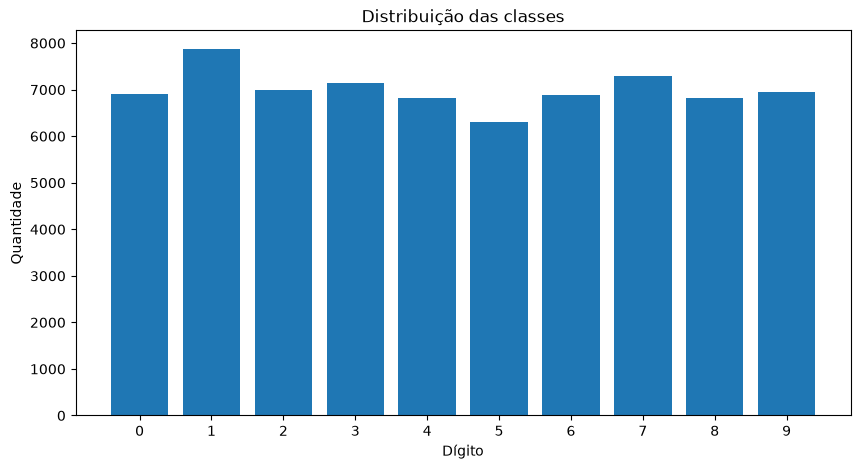

In [23]:
plt.figure(figsize=(10, 5))

plt.bar(
    distribuicao.index.astype(str),
    distribuicao.values
)

plt.xlabel("Dígito")
plt.ylabel("Quantidade")
plt.title("Distribuição das classes")

plt.show()

Mostra um exemplo de cada classe:

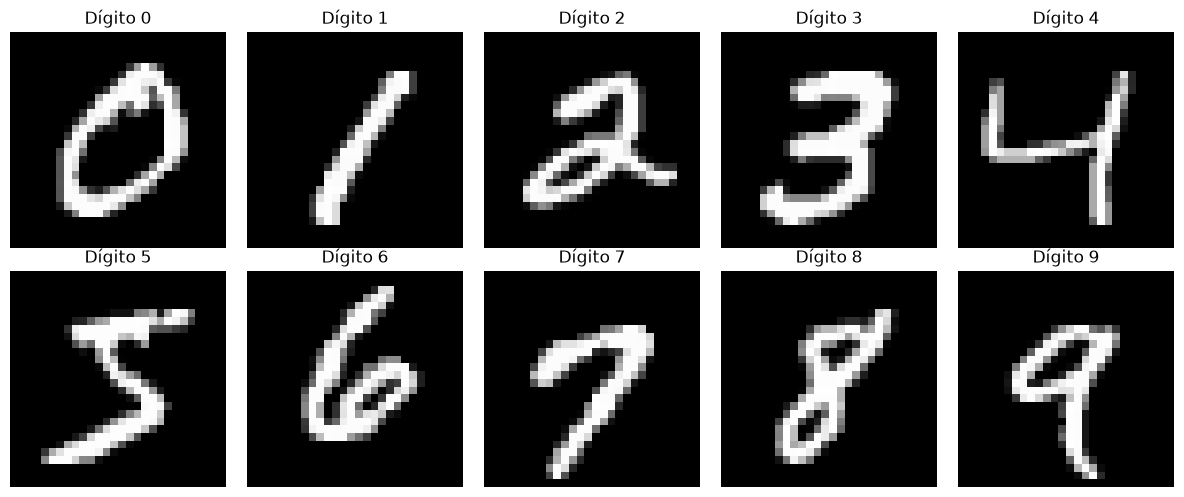

In [24]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(12, 5)
)

for digito in range(10):

    indice = np.where(
        y == digito
    )[0][0]

    imagem = X[indice].reshape(
        28,
        28
    )

    axes.flat[digito].imshow(
        imagem,
        cmap="gray"
    )

    axes.flat[digito].set_title(
        f"Dígito {digito}"
    )

    axes.flat[digito].axis(
        "off"
    )

plt.tight_layout()
plt.show()

Justificativa da Fase 1: o objetivo é conhecer a estrutura do dataset, verificar as classes, visualizar exemplos e confirmar que os pixels variam de 0 a 255. O trabalho pede exatamente dimensões, distribuição das classes, exemplos visuais e a explicação de 28×28 → 784.

## Estrutura dos dados do MNIST

O conjunto de dados **MNIST** é composto por imagens de dígitos manuscritos, representando os números de **0 a 9**. Cada imagem possui dimensões de **28 × 28 pixels** e está em escala de cinza.

### Intensidade dos pixels

Cada pixel da imagem é representado por um valor numérico entre **0 e 255**, indicando sua intensidade:

- **0** → pixel preto;
- **255** → pixel branco;
- **Valores intermediários** → diferentes tons de cinza.

Dessa forma, quanto maior o valor do pixel, mais clara é aquela região da imagem.

### Representação 28 × 28

Originalmente, cada imagem pode ser representada como uma matriz de **28 linhas por 28 colunas**:

**28 × 28 = 784 pixels**

Cada posição dessa matriz corresponde a um pixel da imagem e contém um valor entre 0 e 255.

### Vetorização das imagens

Para utilizar as imagens em muitos algoritmos de Machine Learning, a matriz bidimensional de **28 × 28 pixels** pode ser transformada em um vetor unidimensional.

Assim, os 784 pixels são organizados sequencialmente:

**28 × 28 → 784 features**

Portanto, cada imagem passa a ser representada por **784 características (features)**, em que cada feature corresponde à intensidade de um determinado pixel.

Exemplo simplificado:

Imagem 28 × 28:

    [[0,   0,  25, ...],
     [0, 120, 255, ...],
     [0,  80, 200, ...],
     ...]

Após a vetorização:

    [0, 0, 25, ..., 0, 120, 255, ..., 0, 80, 200, ...]

Dessa maneira, cada linha do conjunto de dados representa **uma imagem**, enquanto as **784 colunas de entrada representam os pixels** dessa imagem.

A variável alvo (*target*) corresponde ao **dígito representado na imagem**, podendo assumir valores inteiros de **0 a 9**.

### Resumo da estrutura

| Característica | Descrição |
|---|---|
| Dimensão original | 28 × 28 pixels |
| Número total de pixels | 784 |
| Intensidade dos pixels | 0 a 255 |
| 0 | Preto |
| 255 | Branco |
| Entrada do modelo | 784 features |
| Classes | Dígitos de 0 a 9 |
| Número de classes | 10 |

Essa transformação permite que algoritmos que trabalham com dados tabulares recebam cada imagem como um conjunto de **784 variáveis numéricas**, preservando as informações de intensidade dos pixels.

Fase 2: Pipeline de Pré-processamento e Divisão dos Dados
Divisão Estratificada: Dividir a base em Treino, Validação e Teste (ex: 70% treino, 10% validação e 20% teste ou 80% treino/validação e 20% teste), garantindo estratificação por classe (stratify=y).
Normalização / Escalonamento: Aplicar o redimensionamento dos pixels para a escala [0.0, 1.0] (dividindo por 255.0 ou via MinMaxScaler/StandardScaler).
Justificar textualmente a importância da normalização para a convergência de modelos lineares e distâncias métricas.


Fase 2 — Dividir os dados

Agora divida em:

70% treino
10% validação
20% teste

In [25]:
#Primeiro separe 20% para teste:
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

In [26]:
#Agora separa 12,5% do restante para validação:
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.125,
    stratify=y_temp,
    random_state=RANDOM_STATE
)

In [27]:
#Confere as dimensões dos conjuntos de dados
print("Treino:", X_train.shape)
print("Validação:", X_val.shape)
print("Teste:", X_test.shape)

Treino: (49000, 784)
Validação: (7000, 784)
Teste: (14000, 784)


Usamos stratify porque queremos manter aproximadamente a mesma proporção de cada dígito em todos os conjuntos.

In [28]:
stratify=y

Fase 2.1 — Normalizar os pixels

Crie esta função:

In [29]:
#Função para normalizar os pixels
def normalizar_pixels(X):

    return (
        X.astype(np.float32)
        / 255.0
    )

In [30]:
#Criação da função para criar o pipeline
def criar_pipeline(modelo):

    return Pipeline([
        (
            "normalizacao",
            FunctionTransformer(
                normalizar_pixels,
                validate=False
            )
        ),
        (
            "modelo",
            modelo
        )
    ])

 ### Normalização dos pixels

Os valores dos pixels são normalizados para o intervalo **[0, 1]**.

A transformação é realizada dividindo cada valor de pixel por **255**:

\[
x_{normalizado} = \frac{x}{255}
\]

Por exemplo:

| Valor original | Valor normalizado |
|---:|---:|
| 0 | 0.000 |
| 64 | 0.251 |
| 128 | 0.502 |
| 192 | 0.753 |
| 255 | 1.000 |

Assim, um pixel com intensidade **128** passa a ter aproximadamente:

\[
\frac{128}{255} \approx 0,502
\]

A normalização mantém a informação visual da imagem, alterando apenas a escala numérica utilizada para representar seus pixels.

### Por que normalizar?

A normalização coloca todas as características em uma escala conhecida e reduz a magnitude dos valores utilizados nos cálculos.

Isso é especialmente importante para modelos sensíveis à escala dos atributos e também facilita o treinamento de modelos baseados em redes neurais.


Fase 3: Implementação e Treinamento dos 3 Modelos
Deve-se obrigatoriamente escolher e treinar 3 modelos distintos, podendo optar por combinações de:
Modelos Clássicos: SVM (Support Vector Machines), Random Forest, KNN (K-Nearest Neighbors), XGBoost / Gradient Boosting, Regressão Logística Multinomial, etc.
Redes Neurais: Perceptron Multicamadas (MLP via Scikit-Learn ou TensorFlow/Keras).
Cada modelo deve possuir ajuste justificado de ao menos 2 hiperparâmetros (ex: n_estimators e max_depth na Random Forest; n_neighbors e weights no KNN; C e kernel no SVM; número de neurônios, taxa de aprendizado ou funções de ativação na Rede Neural).
Caso queiram usar outros modelos não citados acima, é permitido, desde que justificadas as escolhas.



# FASE 3 — Modelos e Hiperparâmetros

Serão comparados:

### KNN
- `n_neighbors`
- `weights`

### Random Forest
- `n_estimators`
- `max_depth`

### MLP
- `hidden_layer_sizes`
- `alpha`


Definindo os hiperparâmetros:


In [31]:
#KNN
parametros_knn = {

    "n_neighbors": [
        3,
        5
    ],

    "weights": [
        "uniform",
        "distance"
    ]
}

No modelo KNN foram testados os parâmetos 3 ou 5 vizinhos e peso uniforme ou peso pela distância.

In [32]:
#Random Forest
parametros_rf = {

    "n_estimators": [
        100,
        200
    ],

    "max_depth": [
        20,
        None
    ],

    "random_state": [
        RANDOM_STATE
    ],

    "n_jobs": [
        -1
    ]
}



No modelo Random Forest foram testados os parâmetros  100 ou 200 árvores, profundidade máxima 20 ou sem limite definido.

In [45]:
#MLP
parametros_mlp = {

    "hidden_layer_sizes": [
        (128,),
        (128, 64)
    ],

    "alpha": [
        0.0001,
        0.001
    ],

    "activation": [
        "relu"
    ],

    "solver": [
        "adam"
    ],

    "max_iter": [
        100
    ],

    "early_stopping": [
        True
    ],

    "random_state": [
        RANDOM_STATE
    ]
}

Aqui estamos testando duas arquiteturas: 128 neurônios, 1128 → 64 neurônios, além de dois níveis de regularização

## Configuração dos hiperparâmetros da MLP

Nesta etapa são definidos os hiperparâmetros que serão testados para o modelo **MLP (Multilayer Perceptron)**.

A MLP é uma **rede neural artificial do tipo feedforward**, formada por uma camada de entrada, uma ou mais camadas ocultas e uma camada de saída. Durante o treinamento, a rede ajusta os pesos das conexões entre os neurônios com o objetivo de minimizar o erro de classificação.

O dicionário `parametros_mlp` define as configurações que poderão ser avaliadas durante a busca pelo melhor modelo.

### `hidden_layer_sizes`

Define a quantidade de **camadas ocultas** e o número de neurônios em cada uma delas.

Foram utilizadas duas possibilidades:

- `(128,)`: uma camada oculta contendo **128 neurônios**;
- `(128, 64)`: duas camadas ocultas, sendo a primeira com **128 neurônios** e a segunda com **64 neurônios**.

Dessa forma, é possível comparar uma arquitetura mais simples com uma rede um pouco mais profunda.

### `alpha`

O parâmetro `alpha` controla a intensidade da **regularização L2** aplicada aos pesos da rede.

Foram testados:

- `0.0001`
- `0.001`

A regularização ajuda a evitar que o modelo se ajuste excessivamente aos dados de treinamento (**overfitting**). Valores maiores de `alpha` aplicam uma penalização maior aos pesos da rede.

### `activation`

Foi utilizada a função de ativação:

`relu`

A **ReLU (Rectified Linear Unit)** pode ser representada por:

`f(x) = max(0, x)`

Isso significa que valores negativos são transformados em zero, enquanto valores positivos são mantidos. É uma função de ativação amplamente utilizada em redes neurais por permitir o aprendizado de relações não lineares.

### `solver`

Foi utilizado o otimizador:

`adam`

O **Adam (Adaptive Moment Estimation)** é um algoritmo responsável por atualizar os pesos da rede durante o treinamento. Ele adapta automaticamente a taxa de aprendizado para diferentes parâmetros e costuma apresentar bom desempenho em problemas de classificação e redes neurais.

### `max_iter`

Foi definido:

`max_iter = 100`

Esse parâmetro estabelece o número máximo de **100 iterações (épocas)** de treinamento.

O treinamento poderá terminar antes desse limite caso o mecanismo de `early_stopping` identifique que não há melhora significativa no desempenho do modelo.

### `early_stopping`

Foi definido:

`early_stopping = True`

O **early stopping** interrompe automaticamente o treinamento quando o desempenho sobre uma parcela dos dados de validação deixa de melhorar.

Essa estratégia possui duas vantagens principais:

1. reduz o tempo de treinamento desnecessário;
2. ajuda a diminuir o risco de **overfitting**.

### `random_state`

Foi utilizado:

`random_state = RANDOM_STATE`

Esse parâmetro controla os processos aleatórios utilizados pelo modelo, como a inicialização dos pesos e a separação dos dados utilizada pelo `early_stopping`.

Manter um valor fixo permite obter maior **reprodutibilidade dos experimentos**, ou seja, executar novamente o notebook em condições semelhantes e obter resultados consistentes.

### Resumo dos hiperparâmetros

| Parâmetro | Valores utilizados | Objetivo |
|---|---|---|
| `hidden_layer_sizes` | `(128,)`, `(128, 64)` | Definir a arquitetura da rede |
| `alpha` | `0.0001`, `0.001` | Controlar a regularização L2 |
| `activation` | `relu` | Introduzir não linearidade |
| `solver` | `adam` | Otimizar os pesos da rede |
| `max_iter` | `100` | Limitar o número de épocas |
| `early_stopping` | `True` | Interromper o treinamento sem melhora |
| `random_state` | `RANDOM_STATE` | Garantir reprodutibilidade |

In [62]:
from sklearn.neural_network import MLPClassifier

mlp_final = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    alpha=0.001,
    solver="adam",
    max_iter=100,
    early_stopping=True,
    random_state=42
)

mlp_final.fit(X_train, y_train)

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(128, ...)"
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.001
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",100
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"early_stopping early_stopping: bool, default=FalseWhether to use early stopping to terminate training when validationscore is not improving. If set to True, it will automatically setaside ``validation_fraction`` of training data as validation andterminate training when validation score is not improving by at least``tol`` for ``n_iter_no_change`` consecutive epochs. The split isstratified, except in a multilabel setting.If early stopping is False, then the training stops when the trainingloss does not improve by more than ``tol`` for ``n_iter_no_change``consecutive passes over the training set.Only effective when solver='sgd' or 'adam'.",True
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating 

In [69]:
print("Número de épocas executadas:", mlp_final.n_iter_)

Número de épocas executadas: 43


In [63]:
print("Melhor score de validação:", mlp_final.best_validation_score_)

Melhor score de validação: 0.9673469387755103


## Convergência do modelo MLP final

Inicialmente, o número máximo de iterações da MLP estava definido como
`max_iter=40`. Durante os experimentos, foi observado um aviso de
convergência indicando que o modelo havia atingido esse limite antes
do encerramento adequado do processo de otimização.

Por esse motivo, o parâmetro foi aumentado para `max_iter=100`,
mantendo `early_stopping=True`.

No treinamento final, foram obtidos os seguintes resultados:

- **Número máximo permitido de épocas:** 100
- **Número de épocas efetivamente executadas:** 43
- **Melhor score de validação interno:** aproximadamente 96,73%

O fato de o treinamento ter terminado após 43 épocas demonstra que
não foi necessário atingir o limite máximo de 100 épocas.

Como o `early_stopping` estava ativado, a MLP monitorou seu desempenho
em uma parcela interna de validação e interrompeu automaticamente o
treinamento quando deixou de apresentar melhora suficiente.

Dessa forma, aumentar `max_iter` de 40 para 100 forneceu margem
suficiente para o processo de otimização, enquanto o `early_stopping`
evitou a realização desnecessária das 100 épocas.

Esse resultado também elimina o problema anteriormente observado,
no qual o treinamento atingia o limite de 40 iterações antes da
convergência.

Fase 3.1 — Criar função de treinamento e validação

In [64]:
def testar_configuracoes(
    nome,
    classe_modelo,
    grade_parametros
):

    resultados = []

    for parametros in ParameterGrid(
        grade_parametros
    ):

        print(
            nome,
            parametros
        )

        modelo = classe_modelo(
            **parametros
        )

        pipeline = criar_pipeline(
            modelo
        )

        inicio = time.perf_counter()

        pipeline.fit(
            X_train,
            y_train
        )

        tempo_treino = (
            time.perf_counter()
            - inicio
        )

        y_pred = pipeline.predict(
            X_val
        )

        accuracy = accuracy_score(
            y_val,
            y_pred
        )

        f1 = f1_score(
            y_val,
            y_pred,
            average="weighted"
        )

        resultados.append({

            "Modelo": nome,

            "Parametros": parametros,

            "Accuracy": accuracy,

            "F1": f1,

            "Tempo_treino":
                tempo_treino
        })

    return pd.DataFrame(
        resultados
    )

In [65]:
#Execute KNN
resultados_knn = testar_configuracoes(
    "KNN",
    KNeighborsClassifier,
    parametros_knn
)

KNN {'n_neighbors': 3, 'weights': 'uniform'}
KNN {'n_neighbors': 3, 'weights': 'distance'}
KNN {'n_neighbors': 5, 'weights': 'uniform'}
KNN {'n_neighbors': 5, 'weights': 'distance'}


In [66]:
#Execute Random Forest
resultados_rf = testar_configuracoes(
    "Random Forest",
    RandomForestClassifier,
    parametros_rf
)

Random Forest {'max_depth': 20, 'n_estimators': 100, 'n_jobs': -1, 'random_state': 42}
Random Forest {'max_depth': 20, 'n_estimators': 200, 'n_jobs': -1, 'random_state': 42}
Random Forest {'max_depth': None, 'n_estimators': 100, 'n_jobs': -1, 'random_state': 42}
Random Forest {'max_depth': None, 'n_estimators': 200, 'n_jobs': -1, 'random_state': 42}


In [67]:
#Execute MLP
resultados_mlp = testar_configuracoes(
    "MLP",
    MLPClassifier,
    parametros_mlp
)

MLP {'activation': 'relu', 'alpha': 0.0001, 'early_stopping': True, 'hidden_layer_sizes': (128,), 'max_iter': 100, 'random_state': 42, 'solver': 'adam'}
MLP {'activation': 'relu', 'alpha': 0.0001, 'early_stopping': True, 'hidden_layer_sizes': (128, 64), 'max_iter': 100, 'random_state': 42, 'solver': 'adam'}
MLP {'activation': 'relu', 'alpha': 0.001, 'early_stopping': True, 'hidden_layer_sizes': (128,), 'max_iter': 100, 'random_state': 42, 'solver': 'adam'}
MLP {'activation': 'relu', 'alpha': 0.001, 'early_stopping': True, 'hidden_layer_sizes': (128, 64), 'max_iter': 100, 'random_state': 42, 'solver': 'adam'}


In [68]:
#Resultados da validação
resultados_validacao = pd.concat(
    [
        resultados_knn,
        resultados_rf,
        resultados_mlp
    ],
    ignore_index=True
)

display(
    resultados_validacao.sort_values(
        "F1",
        ascending=False
    )
)

,Modelo,Parametros,Accuracy,F1,Tempo_treino
11,MLP,"{'activation': 'relu', 'alpha': 0.001, 'early_...",0.978000,0.977996,63.470025
9,MLP,"{'activation': 'relu', 'alpha': 0.0001, 'early...",0.977714,0.977708,57.958339
10,MLP,"{'activation': 'relu', 'alpha': 0.001, 'early_...",0.977000,0.976983,83.856797
8,MLP,"{'activation': 'relu', 'alpha': 0.0001, 'early...",0.974286,0.974279,44.901257
1,KNN,"{'n_neighbors': 3, 'weights': 'distance'}",0.972286,0.972253,0.144264
0,KNN,"{'n_neighbors': 3, 'weights': 'uniform'}",0.971857,0.971815,0.172851
3,KNN,"{'n_neighbors': 5, 'weights': 'distance'}",0.971429,0.971400,0.144104
2,KNN,"{'n_neighbors': 5, 'weights': 'uniform'}",0.969429,0.969374,0.143900
7,Random Forest,"{'max_depth': None, 'n_estimators': 200, 'n_jo...",0.968000,0.967964,28.665352
5,Random Forest,"{'max_depth': 20, 'n_estimators': 200, 'n_jobs...",0.966714,0.966673,22.971327


## Seleção dos melhores hiperparâmetros

Nesta etapa foram avaliadas diferentes combinações de hiperparâmetros para os modelos **KNN**, **Random Forest** e **MLP**.

A comparação foi realizada utilizando o conjunto de validação, considerando principalmente as métricas **Accuracy** e **F1-score**. O tempo de treinamento também foi registrado como informação complementar sobre o custo computacional de cada configuração.

### Melhor configuração da MLP

A MLP apresentou o melhor desempenho entre todas as configurações avaliadas.

A configuração vencedora foi:

* `hidden_layer_sizes = (128, 64)`
* `activation = 'relu'`
* `alpha = 0.001`
* `solver = 'adam'`
* `early_stopping = True`
* `max_iter = 100`
* `random_state = 42`

Resultados na validação:

* **Accuracy: 97,80%**
* **F1-score: aproximadamente 97,80%**
* **Tempo de treinamento na etapa de validação: 62,83 s**

### Melhor configuração do KNN

A configuração vencedora foi:

* `n_neighbors = 3`
* `weights = 'distance'`

Resultados na validação:

* **Accuracy: 97,23%**
* **F1-score: aproximadamente 97,23%**
* **Tempo de treinamento na etapa de validação: 0,15 s**

### Melhor configuração do Random Forest

A configuração vencedora foi:

* `n_estimators = 200`
* `max_depth = None`
* `n_jobs = -1`
* `random_state = 42`

Resultados na validação:

* **Accuracy: 96,80%**
* **F1-score: aproximadamente 96,80%**
* **Tempo de treinamento na etapa de validação: 26,22 s**

### Comparação dos modelos vencedores na validação

| Modelo            |   Accuracy |   F1-score | Tempo de treinamento |
| ----------------- | ---------: | ---------: | -------------------: |
| **MLP**           | **97,80%** | **97,80%** |              62,83 s |
| **KNN**           |     97,23% |     97,23% |               0,15 s |
| **Random Forest** |     96,80% |     96,80% |              26,22 s |

Com base principalmente na **Accuracy e no F1-score**, a **MLP foi selecionada como o modelo de melhor desempenho na etapa de validação**.

Entretanto, o conjunto de teste ainda não deve ser utilizado para escolher o vencedor. Após a seleção das melhores configurações, os modelos selecionados são novamente treinados utilizando os dados destinados ao treinamento final e somente então avaliados no conjunto de teste.

Essa separação evita que informações do conjunto de teste influenciem a escolha dos hiperparâmetros e fornece uma estimativa mais confiável da capacidade de generalização dos modelos.


Fase 3.2 - Escolher os melhores parâmetros:

In [52]:
def melhor_configuracao(df):

    return (
        df.sort_values(
            "F1",
            ascending=False
        )
        .iloc[0]["Parametros"]
    )

In [53]:
melhor_knn = melhor_configuracao(
    resultados_knn
)

melhor_rf = melhor_configuracao(
    resultados_rf
)

melhor_mlp = melhor_configuracao(
    resultados_mlp
)

In [54]:
#Visuaos melhores parametros
print(
    "KNN:",
    melhor_knn
)

print(
    "Random Forest:",
    melhor_rf
)

print(
    "MLP:",
    melhor_mlp
)

KNN: {'n_neighbors': 3, 'weights': 'distance'}
Random Forest: {'max_depth': None, 'n_estimators': 200, 'n_jobs': -1, 'random_state': 42}
MLP: {'activation': 'relu', 'alpha': 0.001, 'early_stopping': True, 'hidden_layer_sizes': (128, 64), 'max_iter': 100, 'random_state': 42, 'solver': 'adam'}


## Melhores hiperparâmetros encontrados

Após a avaliação das diferentes combinações de hiperparâmetros, foram selecionadas as configurações que apresentaram o melhor desempenho para cada algoritmo.

### KNN — K-Nearest Neighbors

A melhor configuração encontrada foi:

- **Número de vizinhos (`n_neighbors`):** 3
- **Pesos (`weights`):** `distance`

O modelo considera os **3 vizinhos mais próximos** para realizar a classificação.

A utilização de `weights='distance'` faz com que os vizinhos mais próximos da amostra analisada tenham maior influência sobre a decisão do modelo. Assim, quanto menor a distância de um vizinho, maior será sua contribuição para a classificação.

**Melhor resultado:**

- Accuracy: **97,23%**
- F1-score: **97,23%**

---

### Random Forest

A melhor configuração encontrada foi:

- **Número de árvores (`n_estimators`):** 200
- **Profundidade máxima (`max_depth`):** `None`
- **Processamento paralelo (`n_jobs`):** -1
- **Estado aleatório (`random_state`):** 42

O valor `n_estimators=200` indica que o modelo utiliza **200 árvores de decisão**.

O parâmetro `max_depth=None` permite que cada árvore cresça sem um limite de profundidade previamente estabelecido, respeitando os demais critérios internos de parada do algoritmo.

O parâmetro `n_jobs=-1` permite utilizar todos os processadores disponíveis para executar operações em paralelo, reduzindo o tempo necessário para o treinamento.

O `random_state=42` garante maior **reprodutibilidade do experimento**.

**Melhor resultado:**

- Accuracy: **96,80%**
- F1-score: **aproximadamente 96,80%**

---

### MLP — Multilayer Perceptron

A melhor configuração encontrada foi:

- **Camadas ocultas (`hidden_layer_sizes`):** `(128, 64)`
- **Função de ativação (`activation`):** `relu`
- **Regularização (`alpha`):** 0.001
- **Otimizador (`solver`):** `adam`
- **Máximo de iterações (`max_iter`):** 40
- **Early stopping:** ativado
- **Estado aleatório (`random_state`):** 42

A arquitetura `(128, 64)` representa uma rede neural com **duas camadas ocultas**:

**Entrada (784 pixels) → 128 neurônios → 64 neurônios → Saída (10 classes)**

A função de ativação **ReLU** permite que a rede aprenda relações não lineares presentes nos dados.

O parâmetro `alpha=0.001` aplica regularização L2, auxiliando no controle do **overfitting**.

O otimizador **Adam** é responsável pela atualização dos pesos da rede durante o treinamento.

O `early_stopping=True` permite interromper o treinamento quando o desempenho no conjunto de validação deixa de melhorar, evitando treinamento desnecessário e ajudando a controlar o overfitting.

**Melhor resultado:**

- Accuracy: **97,80%**
- F1-score: **aproximadamente 97,80%**

---

## Comparação das melhores configurações

| Modelo | Principais hiperparâmetros | Accuracy | F1-score |
|---|---|---:|---:|
| **MLP** | `(128,64)`, alpha=0.001, ReLU, Adam | **97,80%** | **97,80%** |
| **KNN** | k=3, weights=distance | 97,23% | 97,23% |
| **Random Forest** | 200 árvores, max_depth=None | 96,80% | 96,80% |

Os três modelos apresentaram resultados elevados na classificação das imagens do MNIST, todos com acurácia superior a **96%**.

Entretanto, a **MLP apresentou o melhor desempenho entre todas as configurações testadas**, alcançando aproximadamente **97,80% de Accuracy e F1-score**.

Por esse motivo, considerando como critério principal o desempenho preditivo, a configuração da **MLP com duas camadas ocultas de 128 e 64 neurônios foi selecionada como o melhor modelo para as próximas etapas do projeto**.

Fase 3.3 — Treinar os modelos finais

Agora que os parâmetros já foram escolhidos, una treino + validação:

In [55]:
X_train_final = np.concatenate(
    [
        X_train,
        X_val
    ]
)

y_train_final = np.concatenate(
    [
        y_train,
        y_val
    ]
)

In [56]:
#Criar modelos finais
modelos = {

    "KNN":
        criar_pipeline(
            KNeighborsClassifier(
                **melhor_knn
            )
        ),

    "Random Forest":
        criar_pipeline(
            RandomForestClassifier(
                **melhor_rf
            )
        ),

    "MLP":
        criar_pipeline(
            MLPClassifier(
                **melhor_mlp
            )
        )
}

In [57]:
#Treinar modelos finais
tempos_treino = {}

for nome, modelo in modelos.items():

    inicio = time.perf_counter()

    modelo.fit(
        X_train_final,
        y_train_final
    )

    tempo = (
        time.perf_counter()
        - inicio
    )

    tempos_treino[nome] = tempo

    print(
        nome,
        tempo
    )

KNN 0.18034540000371635
Random Forest 31.365317999996478
MLP 64.0527271999963


## Comparação do tempo de treinamento dos modelos vencedores

Após a seleção dos melhores hiperparâmetros, os modelos foram novamente treinados utilizando suas respectivas configurações vencedoras. Os tempos de treinamento obtidos foram:

| Modelo            | Tempo de treinamento |
| ----------------- | -------------------: |
| **KNN**           |           **0,18 s** |
| **Random Forest** |          **31,37 s** |
| **MLP**           |          **64,05 s** |

O **KNN apresentou o menor tempo de treinamento**, aproximadamente 0,18 segundo. Esse comportamento é esperado, pois o KNN é um algoritmo baseado em instâncias e não realiza um processo tradicional de aprendizado de parâmetros. Durante o ajuste (`fit`), ele essencialmente armazena os dados necessários para realizar posteriormente as classificações.

O **Random Forest apresentou tempo intermediário**, necessitando aproximadamente 31,37 segundos. Esse tempo está relacionado à construção das 200 árvores de decisão utilizadas pela configuração selecionada.

A **MLP apresentou o maior tempo de treinamento**, aproximadamente 64,05 segundos. Esse maior custo computacional é esperado devido ao processo iterativo de ajuste dos pesos da rede neural. A configuração final utiliza duas camadas ocultas, com 128 e 64 neurônios, além do otimizador Adam.

Apesar do maior tempo de treinamento, a MLP apresentou o **melhor desempenho preditivo**, atingindo aproximadamente **97,8% de acurácia**, contra aproximadamente **97,23% do KNN** e **96,80% do Random Forest**.

Portanto, existe um compromisso entre **desempenho preditivo e custo computacional**. O KNN possui ajuste extremamente rápido, enquanto a MLP demanda maior tempo de treinamento, mas apresentou a melhor capacidade de classificação entre os modelos avaliados.

É importante destacar que o baixo tempo de treinamento do KNN não significa necessariamente que ele seja o modelo mais rápido durante seu uso. Como grande parte dos cálculos do KNN ocorre no momento da classificação, uma comparação mais completa deve considerar também o **tempo de predição** dos modelos.


##########################################################################

In [71]:
# Criar os modelos finais com os melhores hiperparâmetros

knn_final = criar_pipeline(
    KNeighborsClassifier(**melhor_knn)
)

rf_final = criar_pipeline(
    RandomForestClassifier(**melhor_rf)
)

mlp_final = criar_pipeline(
    MLPClassifier(**melhor_mlp)
)

In [72]:
knn_final.fit(X_train_final, y_train_final)

rf_final.fit(X_train_final, y_train_final)

mlp_final.fit(X_train_final, y_train_final)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('normalizacao', ...), ('modelo', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](10,)","[0,1,2,...,7,8,9]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,784
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function nor...0023694993BA0>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False


In [73]:
import time
import numpy as np


def medir_tempo_predicao(modelo, X, repeticoes=5):
    tempos = []

    for _ in range(repeticoes):
        inicio = time.perf_counter()

        modelo.predict(X)

        fim = time.perf_counter()

        tempos.append(fim - inicio)

    return np.mean(tempos), np.std(tempos)


modelos_finais = {
    "KNN": knn_final,
    "Random Forest": rf_final,
    "MLP": mlp_final
}


for nome, modelo in modelos_finais.items():

    media, desvio = medir_tempo_predicao(
        modelo,
        X_test,
        repeticoes=5
    )

    print(
        f"{nome}: "
        f"{media:.4f} ± {desvio:.4f} segundos"
    )

KNN: 21.7745 ± 1.6831 segundos
Random Forest: 0.6003 ± 0.0697 segundos
MLP: 0.1084 ± 0.0065 segundos


## Comparação do tempo de predição

O tempo de predição também foi avaliado para os três modelos selecionados, utilizando o conjunto de teste e repetindo a medição cinco vezes.

Os resultados obtidos foram:

| Modelo | Tempo médio de predição | Desvio-padrão |
|---|---:|---:|
| **KNN** | **21,7745 s** | 1,6831 s |
| **Random Forest** | **0,6003 s** | 0,0697 s |
| **MLP** | **0,1084 s** | 0,0065 s |

O **KNN apresentou o maior tempo de predição**, apesar de ter apresentado o menor tempo de treinamento.

Esse comportamento ocorre porque o KNN é um algoritmo baseado em instâncias. Durante o treinamento, praticamente não há ajuste de parâmetros. Entretanto, no momento da predição, o modelo precisa calcular as distâncias entre cada nova amostra e os exemplos armazenados no conjunto de treinamento.

Por esse motivo, grande parte do custo computacional do KNN ocorre durante a classificação.

O **Random Forest apresentou tempo de predição significativamente menor**, com aproximadamente 0,60 segundo.

A **MLP apresentou o menor tempo de predição**, necessitando aproximadamente 0,11 segundo para classificar todo o conjunto de teste.

Isso mostra que, embora a MLP possua maior custo durante o treinamento, após treinada ela realiza as predições de forma bastante rápida.

### Relação entre treinamento e predição

| Modelo | Tempo de treinamento | Tempo de predição |
|---|---:|---:|
| **KNN** | 0,18 s | **21,77 s** |
| **Random Forest** | 31,37 s | 0,60 s |
| **MLP** | 64,05 s | **0,11 s** |

Os resultados evidenciam diferentes estratégias computacionais.

O **KNN possui treinamento extremamente rápido**, porém apresenta elevado custo durante a predição.

O **Random Forest apresenta um custo intermediário de treinamento e predição**.

Já a **MLP apresenta o maior tempo de treinamento, mas o menor tempo de predição entre os modelos avaliados**.

Esse resultado é relevante em aplicações nas quais o modelo é treinado uma vez e utilizado posteriormente para realizar muitas classificações. Nesse cenário, o maior custo inicial de treinamento da MLP pode ser compensado pela elevada velocidade de predição.

Os resultados que temos até aqui vieram da sua tabela de validação. Para declarar a MLP como vencedora definitiva no conjunto de teste, o ideal agora é calcular Accuracy e F1 dos três modelos em X_test. Isso é a última comparação que falta para fechar o trabalho corretamente.

In [81]:
import joblib
from pathlib import Path

PASTA_MODELOS = Path("../models")

PASTA_MODELOS.mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    mlp_final,
    PASTA_MODELOS / "mlp_final.joblib"
)

['..\\models\\mlp_final.joblib']

### Fase 4: Avaliação Comparativa de Desempenho
Para cada um dos 3 modelos avaliados no conjunto de teste independente, apresentar:
Matriz de Confusão completa (10 x 10) com mapa de calor (heatmap).
Tabela comparativa consolidada contendo:
Acurácia Global (Accuracy)
Precisão Média Ponderada (Precision)
Revocação/Sensibilidade Média Ponderada (Recall)
F1-Score Ponderado (F1-Score)
Sugestão: classification_report
Célula de conclusão técnica apontando: qual dígito apresentou a maior taxa de confusão (ex: 4 vs 9, 3 vs 5, 7 vs 1), qual modelo obteve a melhor performance e qual o impacto do custo computacional (tempo de treino vs acurácia).


In [74]:
#Avaliação dos modelos finais no conjunto de teste
resultados_finais = []

predicoes = {}

In [75]:
for nome, modelo in modelos.items():

    inicio = time.perf_counter()

    y_pred = modelo.predict(
        X_test
    )

    tempo_predicao = (
        time.perf_counter()
        - inicio
    )

    predicoes[nome] = y_pred

    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    resultados_finais.append({

        "Modelo": nome,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1": f1,

        "Tempo_treino":
            tempos_treino[nome],

        "Tempo_predicao":
            tempo_predicao
    })

In [76]:
#Mostrando tabela de resultados finais
df_resultados = pd.DataFrame(
    resultados_finais
)

df_resultados = (
    df_resultados
    .sort_values(
        "F1",
        ascending=False
    )
)

display(
    df_resultados
)

,Modelo,Accuracy,Precision,Recall,F1,Tempo_treino,Tempo_predicao
2,MLP,0.980071,0.980077,0.980071,0.980062,64.052727,0.126556
0,KNN,0.973214,0.973408,0.973214,0.973185,0.180345,25.033448
1,Random Forest,0.967786,0.967806,0.967786,0.967771,31.365318,0.708309


## Conclusão e seleção do modelo final

Após a seleção dos melhores hiperparâmetros, os modelos KNN,
Random Forest e MLP foram avaliados no conjunto de teste, que não
foi utilizado durante a escolha das configurações.

Os resultados finais foram:

| Modelo | Accuracy | Precision | Recall | F1-score |
|---|---:|---:|---:|---:|
| **MLP** | **98,01%** | **98,01%** | **98,01%** | **98,01%** |
| KNN | 97,32% | 97,34% | 97,32% | 97,32% |
| Random Forest | 96,78% | 96,78% | 96,78% | 96,78% |

A **MLP (Multilayer Perceptron) foi selecionada como o melhor modelo
final**, pois apresentou os maiores valores de Accuracy, Precision,
Recall e F1-score no conjunto de teste.

A MLP alcançou aproximadamente **98,01% de acurácia**, superando o
KNN, com 97,32%, e o Random Forest, com 96,78%.

Além do melhor desempenho preditivo, a MLP apresentou o menor tempo
de predição entre os modelos avaliados:

- MLP: aproximadamente **0,13 segundo**
- Random Forest: aproximadamente **0,71 segundo**
- KNN: aproximadamente **25,03 segundos**

Embora a MLP tenha apresentado o maior tempo de treinamento,
aproximadamente 64,05 segundos, esse custo ocorre principalmente na
fase de aprendizado. Depois de treinada, a rede realizou as
classificações de forma muito rápida.

O KNN apresentou comportamento oposto: seu treinamento foi
extremamente rápido, porém apresentou o maior tempo de predição,
característica esperada para um algoritmo baseado em instâncias.

A configuração final selecionada para a MLP foi:

- `hidden_layer_sizes = (128, 64)`
- `activation = 'relu'`
- `alpha = 0.001`
- `solver = 'adam'`
- `max_iter = 100`
- `early_stopping = True`
- `random_state = 42`

Embora tenham sido permitidas até 100 épocas, o mecanismo de
`early_stopping` encerrou o treinamento após 43 épocas.

Portanto, considerando conjuntamente **desempenho de classificação,
capacidade de generalização e velocidade de predição**, a MLP
apresentou o melhor resultado geral para a classificação dos
dígitos manuscritos do conjunto MNIST.

### Fase 4.1 - Matriz de confusão

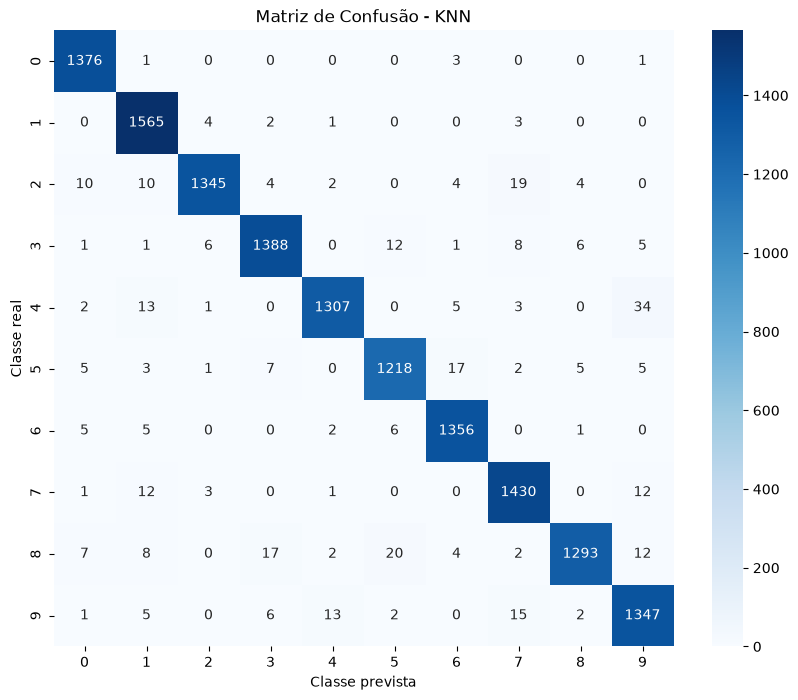

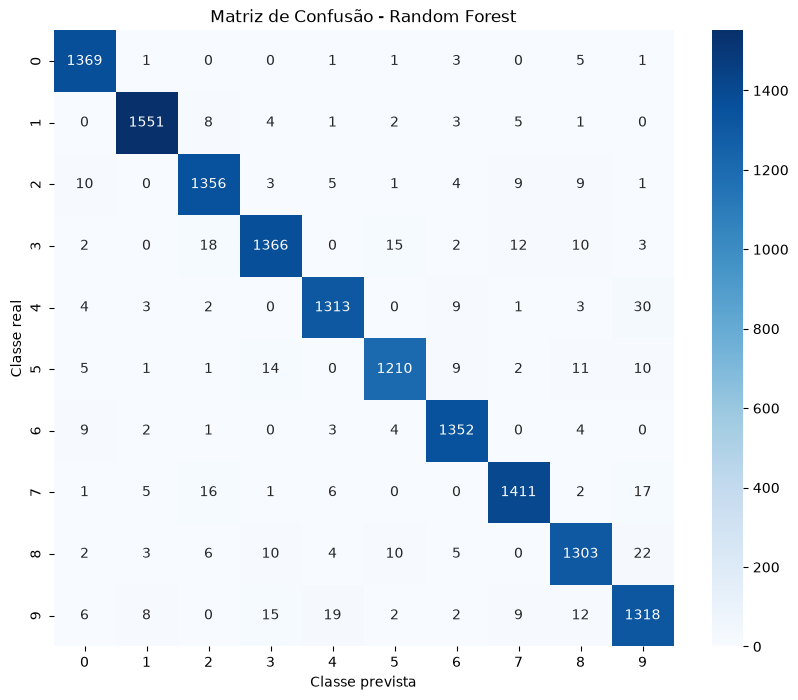

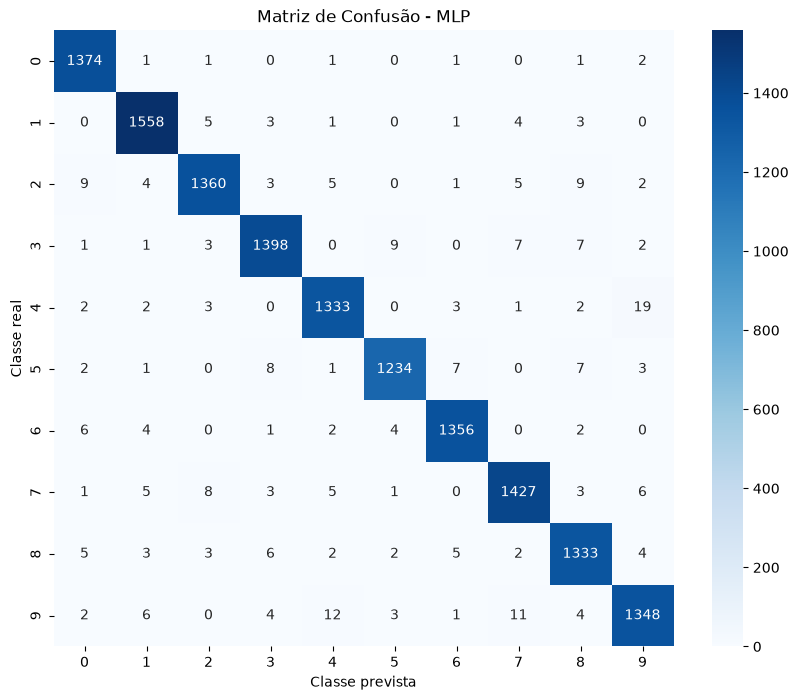

In [77]:
#Matriz de confusão para cada modelo
for nome, y_pred in predicoes.items():

    cm = confusion_matrix(
        y_test,
        y_pred,
        labels=range(10)
    )

    plt.figure(
        figsize=(10, 8)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=range(10),
        yticklabels=range(10)
    )

    plt.xlabel(
        "Classe prevista"
    )

    plt.ylabel(
        "Classe real"
    )

    plt.title(
        f"Matriz de Confusão - {nome}"
    )

    plt.show()

In [78]:
from sklearn.metrics import confusion_matrix
import numpy as np

modelos_finais = {
    "KNN": knn_final,
    "Random Forest": rf_final,
    "MLP": mlp_final
}

for nome, modelo in modelos_finais.items():

    # Predições
    y_pred = modelo.predict(X_test)

    # Matriz de confusão
    cm = confusion_matrix(y_test, y_pred)

    # Total de erros por dígito
    erros_por_digito = cm.sum(axis=1) - np.diag(cm)

    # Dígito com maior número de erros
    digito_mais_confundido = np.argmax(erros_por_digito)

    print(f"\n{nome}")
    print(f"Dígito mais confundido: {digito_mais_confundido}")
    print(f"Total de erros: {erros_por_digito[digito_mais_confundido]}")


KNN
Dígito mais confundido: 8
Total de erros: 72

Random Forest
Dígito mais confundido: 9
Total de erros: 73

MLP
Dígito mais confundido: 9
Total de erros: 43


In [79]:
from sklearn.metrics import confusion_matrix
import numpy as np

modelos_finais = {
    "KNN": knn_final,
    "Random Forest": rf_final,
    "MLP": mlp_final
}

for nome, modelo in modelos_finais.items():

    y_pred = modelo.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)

    # Total de erros de cada dígito
    erros_por_digito = cm.sum(axis=1) - np.diag(cm)

    # Dígito com maior número total de erros
    digito = np.argmax(erros_por_digito)

    # Copiar a linha desse dígito
    confusoes = cm[digito].copy()

    # Retirar os acertos
    confusoes[digito] = 0

    # Classe incorreta mais frequente
    confundido_com = np.argmax(confusoes)

    print(f"\n{nome}")
    print(f"Dígito mais confundido: {digito}")
    print(f"Total de erros: {erros_por_digito[digito]}")
    print(
        f"Mais frequentemente confundido com: "
        f"{confundido_com} ({confusoes[confundido_com]} vezes)"
    )


KNN
Dígito mais confundido: 8
Total de erros: 72
Mais frequentemente confundido com: 5 (20 vezes)

Random Forest
Dígito mais confundido: 9
Total de erros: 73
Mais frequentemente confundido com: 4 (19 vezes)

MLP
Dígito mais confundido: 9
Total de erros: 43
Mais frequentemente confundido com: 4 (12 vezes)


## Análise dos dígitos mais confundidos

A partir das matrizes de confusão, foi identificado o dígito que
apresentou o maior número total de classificações incorretas em cada
modelo.

Os resultados foram:

| Modelo | Dígito mais confundido | Total de erros | Principal confusão |
|---|---:|---:|---|
| **KNN** | **8** | 72 | 8 → 5 (20 vezes) |
| **Random Forest** | **9** | 73 | 9 → 4 (19 vezes) |
| **MLP** | **9** | **43** | 9 → 4 (12 vezes) |

### KNN

No KNN, o dígito **8** apresentou o maior número total de erros,
com **72 classificações incorretas**.

Dentro desses erros, a confusão mais frequente ocorreu entre os
dígitos **8 e 5**, com o número 8 sendo classificado como 5 em
**20 casos**.

### Random Forest

No Random Forest, o dígito **9** foi o mais difícil de classificar,
apresentando **73 erros**.

A principal confusão ocorreu entre **9 e 4**, sendo o dígito 9
classificado como 4 em **19 casos**.

### MLP

Na MLP, o dígito que apresentou maior número de erros também foi
o **9**, porém com apenas **43 classificações incorretas**.

A principal confusão ocorreu novamente com o dígito **4**, sendo
observados **12 casos de 9 classificado como 4**.

### Comparação

Os resultados mostram que os modelos apresentam dificuldades
diferentes na classificação de determinados padrões manuscritos.

O KNN apresentou maior dificuldade com o dígito **8**, principalmente
em sua diferenciação do número 5.

Já o Random Forest e a MLP apresentaram maior dificuldade com o
dígito **9**, principalmente em sua diferenciação do número 4.

Entretanto, mesmo considerando sua classe com maior número de erros,
a **MLP apresentou somente 43 erros**, valor consideravelmente menor
que os 72 erros do KNN e os 73 erros do Random Forest.

Essa análise das matrizes de confusão reforça os resultados das
métricas globais e contribui para a escolha da **MLP como o modelo
de melhor desempenho geral**.